<a href="https://colab.research.google.com/github/HiveCase/DA4001-AI/blob/main/Assignments/Week8/News_Summarization_Sentiment_Agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  News Summarization & Sentiment Analysis Agent with LangGraph

In this notebook we build a **complete news-processing workflow** using [LangGraph](https://github.com/langchain-ai/langgraph).

---

##  Objectives
- Set up a LangGraph workflow
- Define **state, tools, and nodes** for news processing
- Use a **tool** to fetch article text (from a URL)
- Use a **Groq LLM** to summarize the content
- Use a **rule-based tool** for sentiment analysis
- Visualize the workflow
- Execute on example articles and get a **structured response**

---

##  1. Install Required Packages


In [1]:
%pip install -q langgraph langchain_groq requests beautifulsoup4 pydot networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.5 MB/s eta 0:00:00


## 2. Import & API Key

In [2]:
import os, re, json
from getpass import getpass
from typing import List, Dict, Any, Optional, TypedDict

# langgraph and model
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq

# tools: fetching a web article
import requests
from bs4 import BeautifulSoup

# visualization / display
from IPython.display import Image, display

In [3]:
# On Google Colab, store your key in the secrets panel (key icon) as 'groq_api_key'.
try:
    from google.colab import userdata
    os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
except Exception:
    if not os.environ.get("GROQ_API_KEY"):
        os.environ["GROQ_API_KEY"] = getpass("Enter your GROQ API key: ")

In [4]:
# Step 2: Initialize LLM
llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0)

# **The high-level workflow for our agent is:**

1. **Fetch** the article from a URL or from pasted text

2. **Summarize** the article content using the LLM

3. **Analyze sentiment** using a rule-based tool (Positive / Negative / Neutral)

4. **Format** a structured response with the summary and sentiment

The chosen flow is linear:

`START → fetch → summarize → sentiment → results → END`


In [5]:
# Step 1: Define the state structure
class NewsState(TypedDict, total=False):
    # inputs (provide one of these)
    url: Optional[str]            # a news article URL
    raw_text: Optional[str]       # or pre-provided article text

    # produced along the pipeline
    article_text: str             # text after the fetch step
    summary: str                  # LLM-generated summary
    sentiment: str                # POSITIVE / NEGATIVE / NEUTRAL
    sentiment_score: float        # signed score in [-1, 1]
    result: Dict[str, Any]        # final structured response
    error: Optional[str]          # populated if a step fails

## 3. Define the Tools

The assignment asks for **tools** to fetch content and to analyze sentiment.
We keep both deterministic (no LLM), so they are fast and reproducible.


In [6]:
# Tool 1: fetch article text from a URL, or pass raw text through
def fetch_news(url: str = None, raw_text: str = None) -> str:
    if raw_text and raw_text.strip():
        return re.sub(r"\s+", " ", raw_text).strip()

    if not url:
        raise ValueError("Provide either a URL or raw_text.")

    headers = {"User-Agent": "Mozilla/5.0 (news-agent/1.0)"}
    resp = requests.get(url, headers=headers, timeout=20)
    resp.raise_for_status()

    soup = BeautifulSoup(resp.text, "html.parser")
    for tag in soup(["script", "style", "nav", "header", "footer", "aside"]):
        tag.decompose()

    article = soup.find("article")
    container = article if article else soup
    paras = [p.get_text(" ", strip=True) for p in container.find_all("p")]
    text = " ".join(paras) if paras else soup.get_text(" ", strip=True)

    text = re.sub(r"\s+", " ", text).strip()
    if len(text) < 40:
        raise ValueError("Could not extract meaningful article text.")
    return text

In [7]:
# Tool 2: rule-based (lexicon) sentiment analysis with negation handling
POSITIVE_WORDS = {
    "good","great","excellent","positive","success","successful","win","wins",
    "won","gain","gains","growth","grow","surge","soar","boost","record",
    "strong","improve","improved","improvement","profit","hope","hopeful",
    "breakthrough","celebrate","praise","optimistic","rise","rising","recover",
    "recovery","benefit","advance","opportunity",
}
NEGATIVE_WORDS = {
    "bad","poor","terrible","negative","fail","failed","failure","loss","losses",
    "lose","lost","decline","drop","fall","falls","crash","crisis","weak","worse",
    "worst","risk","threat","concern","concerns","fear","fears","warn","warning",
    "cut","cuts","layoff","layoffs","recession","damage","danger","conflict",
    "protest","violence","death","dead","attack","collapse","shortage","scandal",
    "controversy",
}
NEGATIONS = {"not","no","never","without","hardly","barely"}

def analyze_sentiment(text: str) -> dict:
    tokens = re.findall(r"[a-zA-Z']+", text.lower())
    pos = neg = 0
    for i, tok in enumerate(tokens):
        negated = i > 0 and tokens[i-1] in NEGATIONS
        if tok in POSITIVE_WORDS:
            neg += 1 if negated else 0
            pos += 0 if negated else 1
        elif tok in NEGATIVE_WORDS:
            pos += 1 if negated else 0
            neg += 0 if negated else 1

    total = pos + neg
    score = 0.0 if total == 0 else round((pos - neg) / total, 3)
    if score > 0.15:
        label = "POSITIVE"
    elif score < -0.15:
        label = "NEGATIVE"
    else:
        label = "NEUTRAL"
    return {"label": label, "score": score}

## 4. Define the Nodes

Each node reads from the state and returns a small update.

In [8]:
# Node 1: fetch
def fetch_node(state: NewsState):
    print("Fetching article...")
    try:
        text = fetch_news(url=state.get("url"), raw_text=state.get("raw_text"))
        return {"article_text": text}
    except Exception as e:
        return {"error": f"fetch failed: {e}"}


# Node 2: summarize (LLM)
def summarize_node(state: NewsState):
    print("Summarizing with LLM...")
    if state.get("error"):
        return {}
    prompt = f"""You are a concise news editor. Summarize the article below in
3-4 sentences. Capture the key facts only; do not add opinions.

ARTICLE:
{state['article_text'][:6000]}

SUMMARY:"""
    result = llm.invoke(prompt)
    return {"summary": result.content.strip()}


# Node 3: sentiment (tool)
def sentiment_node(state: NewsState):
    print("Analyzing sentiment...")
    if state.get("error"):
        return {}
    s = analyze_sentiment(state.get("article_text", ""))
    return {"sentiment": s["label"], "sentiment_score": s["score"]}


# Node 4: format the structured response
def format_node(state: NewsState):
    print("Formatting response...")
    result = {
        "summary": state.get("summary", ""),
        "sentiment": {
            "label": state.get("sentiment", "NEUTRAL"),
            "score": state.get("sentiment_score", 0.0),
        },
        "error": state.get("error"),
    }
    return {"result": result}

## 5. Build the Graph

In [23]:
graph = StateGraph(NewsState)
graph.add_node("fetch", fetch_node)
graph.add_node("summarize", summarize_node)
graph.add_node("sentiment", sentiment_node)
graph.add_node("results", format_node)

In [24]:
graph.add_edge(START, "fetch")
graph.add_edge("fetch", "summarize")
graph.add_edge("summarize", "sentiment")
graph.add_edge("sentiment", "results")
graph.add_edge("results", END)

In [25]:
compiled_graph = graph.compile()

## 6. Visualize the Workflow

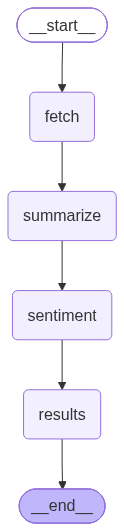

In [26]:
display(Image(compiled_graph.get_graph().draw_mermaid_png()))

## 7. Run on Example Articles

Provide **either** `raw_text` **or** a `url`. Below are two pasted samples
(one positive, one negative). Uncomment the URL example to fetch a live page.


In [13]:
positive_article = (
    "Global technology firm NovaTech reported record quarterly earnings on "
    "Tuesday, driven by strong growth in its cloud computing division. Revenue "
    "surged 28% year over year, beating analyst expectations and boosting the "
    "company's stock in early trading. Chief Executive Maria Alvarez praised "
    "the team's performance and said the company would expand hiring. Analysts "
    "described the results as a breakthrough quarter and expressed optimism."
)

negative_article = (
    "Shares of retailer BrightMart crashed nearly 20% on Wednesday after the "
    "company warned of a sharp decline in sales and announced sweeping layoffs. "
    "The struggling chain said weak consumer demand and rising costs had pushed "
    "it into a deepening crisis. Executives cut the annual profit forecast and "
    "cautioned that more store closures were likely. Employees protested outside "
    "the headquarters following news of the job cuts."
)

In [14]:
# --- Run 1: positive article (pasted text) ---
final_state = compiled_graph.invoke({"raw_text": positive_article})

print("\n=== Structured Response ===")
print(json.dumps(final_state["result"], indent=2, ensure_ascii=False))

Fetching article...
Summarizing with LLM...
Analyzing sentiment...
Formatting response...

=== Structured Response ===
{
  "summary": "NovaTech announced record quarterly earnings, with revenue up 28% year over year, largely due to growth in its cloud computing division. The results surpassed analyst expectations and lifted the company’s stock in early trading. CEO Maria Alvarez praised the team’s performance and said the firm will expand hiring. Analysts called the quarter a breakthrough and expressed optimism.",
  "sentiment": {
    "label": "POSITIVE",
    "score": 1.0
  },
  "error": null
}


In [15]:
# --- Run 2: negative article (pasted text) ---
final_state = compiled_graph.invoke({"raw_text": negative_article})

print("\n=== Structured Response ===")
print(json.dumps(final_state["result"], indent=2, ensure_ascii=False))

Fetching article...
Summarizing with LLM...
Analyzing sentiment...
Formatting response...

=== Structured Response ===
{
  "summary": "BrightMart shares fell almost 20% after the retailer warned of a sharp decline in sales and announced sweeping layoffs. The company cited weak consumer demand and rising costs, cut its annual profit forecast, and said additional store closures were likely. Employees protested outside the headquarters following the news of the job cuts.",
  "sentiment": {
    "label": "NEGATIVE",
    "score": -0.5
  },
  "error": null
}


In [17]:
# --- Run 3: fetch a live URL instead of pasting text ---
final_state = compiled_graph.invoke({"url": "https://www.thehindu.com/business/as-vikram-1-reaches-orbit-skyroot-faces-a-steep-climb-to-business-success/article71238228.ece"})
print(json.dumps(final_state["result"], indent=2, ensure_ascii=False))

Fetching article...
Summarizing with LLM...
Analyzing sentiment...
Formatting response...
{
  "summary": "Skyroot Aerospace successfully launched its first privately developed orbital rocket, Vikram‑1, from the Satish Dhawan Space Centre on 18 July 2026. The four‑stage vehicle, which uses solid‑fuel first three stages and liquid‑fuel fourth stage, carried a payload of 290 kg to a 500‑km sun‑synchronous orbit and 480 kg to a low‑inclination orbit, completing a developmental flight called “Aagaman.” The launch marked India’s first private orbital launch, following the government’s 2020 opening of the domestic space sector to private firms and the company’s earlier suborbital Vikram‑S flight in 2022. Skyroot plans two more developmental flights before a market‑ready launch, with future projects including Vikram‑2 (1,000 kg capacity) and a fully reusable launch vehicle.",
  "sentiment": {
    "label": "POSITIVE",
    "score": 0.778
  },
  "error": null
}


---

##  Summary

- **Fetching** and **sentiment** are handled by deterministic **tools**.
- The **LLM** (Groq) is used only for **summarization**.
- **LangGraph** ties the steps into one clear pipeline and returns a
  **structured response** (`summary` + `sentiment`).

You can extend this by adding a conditional edge (e.g. skip summarization for
very short text) or swapping the rule-based sentiment for a model-based one.
